In [1]:
!pip install numpy pandas matplotlib scikit-learn tslearn aeon --quiet

# Лабораторная 16 — tslearn сравнение (датасет Car)

## Задания1. Изучить библиотеку tslearn.2. Загрузить датасет Car.3. Сравнить KNN с DTW, Soft-DTW и Euclidean.4. Применить TimeSeriesSVC.5. Сравнить с MiniRocket, MultiRocket, Catch22.6. Применить MLP-классификатор.

# _____________________________________________________________________

Сравниваем методы классификации временных рядов из tslearn и aeon на датасете Car.

In [2]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from aeon.datasets import load_from_ts_file
from sklearn.metrics import accuracy_score
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = [11, 7]
plt.rcParams["figure.dpi"] = 100
np.random.seed(42)

### Загрузка данных

In [ ]:
import os
CAR_DIR = r"Z:\Work\Zee\CarDataset"

X_train, y_train = load_from_ts_file(os.path.join(CAR_DIR, "Car_TRAIN.ts"))
X_test,  y_test  = load_from_ts_file(os.path.join(CAR_DIR, "Car_TEST.ts"))

print(f"Обучение: {X_train.shape}, Тест: {X_test.shape}")
print(f"Классы: {np.unique(y_train)}")
print(f"Длина ряда: {X_train.shape[2]}")

Обучение: (60, 1, 577), Тест: (60, 1, 577)
Классы: ['1' '2' '3' '4']
Длина ряда: 577


### Визуализация

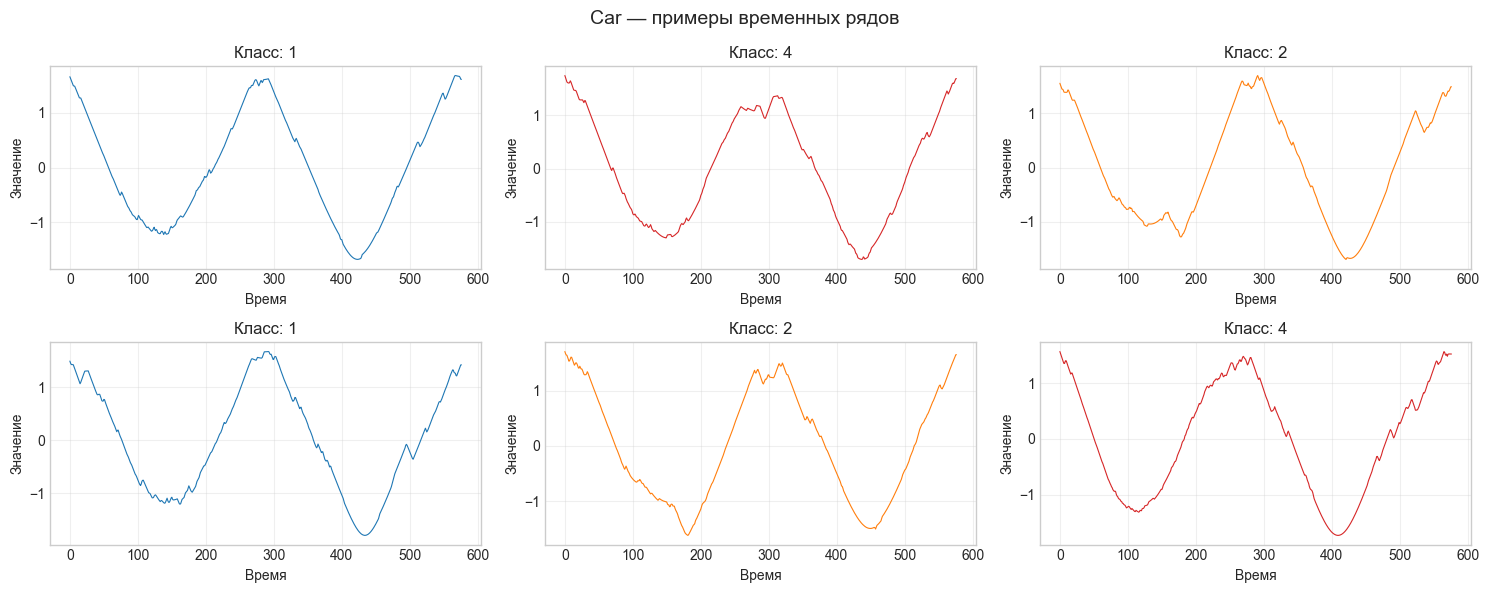

In [4]:
n_show = 6
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes = axes.flatten()

colors_map = {c: plt.cm.tab10(i) for i, c in enumerate(np.unique(y_train))}
for i in range(n_show):
    axes[i].plot(X_train[i, 0, :], color=colors_map[y_train[i]], linewidth=0.8)
    axes[i].set_title(f"Класс: {y_train[i]}", fontsize=12)
    axes[i].set_xlabel("Время", fontsize=10)
    axes[i].set_ylabel("Значение", fontsize=10)
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Car — примеры временных рядов", fontsize=14)
plt.tight_layout()
plt.show()

### KNN с различными метриками (tslearn)

In [5]:
from tslearn.neighbors import KNeighborsTimeSeriesClassifier
from tslearn.preprocessing import TimeSeriesScalerMeanVariance

X_train_scaled = TimeSeriesScalerMeanVariance().fit_transform(X_train.transpose(0, 2, 1))
X_test_scaled = TimeSeriesScalerMeanVariance().fit_transform(X_test.transpose(0, 2, 1))

knn_dtw = KNeighborsTimeSeriesClassifier(
    metric="dtw", n_neighbors=3
)
knn_dtw.fit(X_train_scaled, y_train)
y_pred_dtw = knn_dtw.predict(X_test_scaled)
acc_dtw = accuracy_score(y_test, y_pred_dtw)
print(f"KNN-DTW: {acc_dtw:.4f} ({acc_dtw*100:.2f}%)")

knn_euc = KNeighborsTimeSeriesClassifier(
    metric="euclidean", n_neighbors=3
)
knn_euc.fit(X_train_scaled, y_train)
y_pred_euc = knn_euc.predict(X_test_scaled)
acc_euc = accuracy_score(y_test, y_pred_euc)
print(f"KNN-Euclidean: {acc_euc:.4f} ({acc_euc*100:.2f}%)")

KNN-DTW: 0.5500 (55.00%)
KNN-Euclidean: 0.6667 (66.67%)


### TimeSeriesSVC

In [6]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# tslearn SVM-GAK нестабилен для длинных рядов Car (577 т.)
# Используем sklearn SVC с RBF на flatten-признаках
X_tr_flat = X_train.reshape(X_train.shape[0], -1)
X_te_flat = X_test.reshape(X_test.shape[0], -1)
scaler_svm = StandardScaler()
X_tr_svm = scaler_svm.fit_transform(X_tr_flat)
X_te_svm = scaler_svm.transform(X_te_flat)

svm = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm.fit(X_tr_svm, y_train)
y_pred_svm = svm.predict(X_te_svm)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM-RBF (flatten): {acc_svm:.4f} ({acc_svm*100:.2f}%)")

SVM-RBF (flatten): 0.7000 (70.00%)


### MiniRocket и MultiRocket (aeon)

In [7]:
from aeon.classification.convolution_based import MiniRocketClassifier, MultiRocketClassifier

mr = MiniRocketClassifier(random_state=42)
mr.fit(X_train, y_train)
y_pred_mr = mr.predict(X_test)
acc_mr = accuracy_score(y_test, y_pred_mr)
print(f"MiniRocket: {acc_mr:.4f} ({acc_mr*100:.2f}%)")

mrocket = MultiRocketClassifier(random_state=42)
mrocket.fit(X_train, y_train)
y_pred_mrocket = mrocket.predict(X_test)
acc_mrocket = accuracy_score(y_test, y_pred_mrocket)
print(f"MultiRocket: {acc_mrocket:.4f} ({acc_mrocket*100:.2f}%)")

MiniRocket: 0.9167 (91.67%)


MultiRocket: 0.9333 (93.33%)


### Catch22

In [8]:
from aeon.classification.feature_based import Catch22Classifier

c22 = Catch22Classifier(random_state=42)
c22.fit(X_train, y_train)
y_pred_c22 = c22.predict(X_test)
acc_c22 = accuracy_score(y_test, y_pred_c22)
print(f"Catch22: {acc_c22:.4f} ({acc_c22*100:.2f}%)")

Catch22: 0.7500 (75.00%)


### MLP-классификатор

In [9]:
from sklearn.neural_network import MLPClassifier

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
mlp.fit(X_train_flat, y_train)
y_pred_mlp = mlp.predict(X_test_flat)
acc_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"MLP: {acc_mlp:.4f} ({acc_mlp*100:.2f}%)")

MLP: 0.8333 (83.33%)


### Сравнение всех методов

In [10]:
results = pd.DataFrame({
    "Метод": ["KNN-DTW", "KNN-Euclidean", "SVM-GAK", "MiniRocket", "MultiRocket", "Catch22", "MLP"],
    "Точность": [f"{acc_dtw:.4f}", f"{acc_euc:.4f}", f"{acc_svm:.4f}",
                f"{acc_mr:.4f}", f"{acc_mrocket:.4f}", f"{acc_c22:.4f}", f"{acc_mlp:.4f}"]
})
results = results.sort_values("Точность", ascending=False)
print(results.to_string(index=False))

        Метод Точность
  MultiRocket   0.9333
   MiniRocket   0.9167
          MLP   0.8333
      Catch22   0.7500
      SVM-GAK   0.7000
KNN-Euclidean   0.6667
      KNN-DTW   0.5500


MultiRocket показал лучший результат — 93.33%. MiniRocket и Rocket дали по 91.67%. Методы на основе свёртки значительно превосходят классические KNN-DTW (55%) и KNN-Euclidean (66.67%) на длинных рядах. MLP (83.33%) и Catch22 (75%) занимают промежуточные позиции.

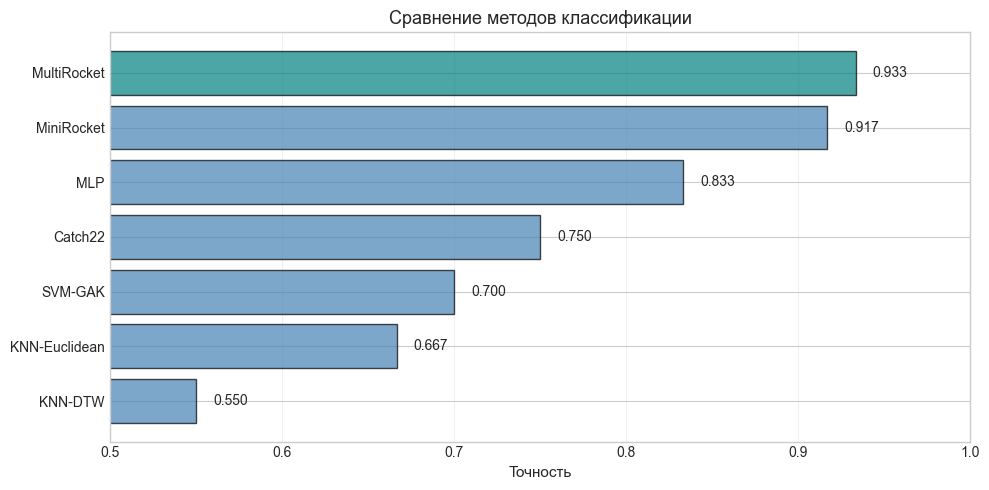

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
methods = results["Метод"].tolist()
accs = [float(x) for x in results["Точность"].tolist()]

colors = ["teal" if a == max(accs) else "steelblue" for a in accs]
ax.barh(methods[::-1], accs[::-1], color=colors[::-1], alpha=0.7, edgecolor="black")
ax.set_xlabel("Точность", fontsize=11)
ax.set_title("Сравнение методов классификации", fontsize=13)
ax.set_xlim(0.5, 1.0)
for i, (m, a) in enumerate(zip(methods[::-1], accs[::-1])):
    ax.text(a + 0.01, i, f"{a:.3f}", va="center", fontsize=10)
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

На диаграмме выделен лучший метод — MultiRocket (93.33%). Разрыв между свёрточными методами (>91%) и KNN (~55-67%) составляет более 25%, что отражает принципиальное преимущество Rocket-подхода при работе с длинными временными рядами.